In [2]:

import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
import category_encoders as ce

In [10]:
filepath = "../Train/task3/introml_2024_task32_train.csv"
df = pd.read_csv(filepath)

# 前處理
cols = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'class'] # 0/1變數, class 分類

for c in cols:
    df[c] = df[c].apply(lambda x: x if x=='?' else int(x[-1]))

df.replace("?", np.nan, inplace=True)


from sklearn.impute import KNNImputer
col1 = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
col2 = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']
imputer = KNNImputer(n_neighbors=5)
df_imputed_col2 = imputer.fit_transform(df[col2])
df_imputed_col2

df_imputed_col1 = imputer.fit_transform(df[col1])
df_imputed_col1.round()
df_imputed1 = pd.DataFrame(df_imputed_col1.round(), columns=col1)

df_imputed2 = pd.DataFrame(df_imputed_col2, columns=col2)

df2=pd.concat([df_imputed1, df_imputed2, df.iloc[:,-1]], axis=1)


from sklearn.preprocessing import MinMaxScaler
mmScaler = MinMaxScaler()
df2[['f15']] = mmScaler.fit_transform(df2[['f15']])

df2.insert(len(df2.columns)-1, 'f20', df2['f15']+ df2['f7']) 
# df2.insert(len(df2.columns)-1, 'f21', df2['f0'] + df2['f2']) 
# df2.insert(len(df2.columns)-1, 'f22', df2['f1'] * df2['f6']) 
df2.insert(len(df2.columns)-1, 'f23', df2['f2'] * df2['f10']) 


df2['f10'] = np.exp(df2['f10'])  # log(1 + x) 防止 log(0)

X = df2.iloc[:, :-1]
y = df2.iloc[:, -1] 

X

/var/folders/z8/tkcn56l93cb258d6cngvzl1h0000gn/T/ipykernel_8005/1464436814.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("?", np.nan, inplace=True)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f20,f23
0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.5812,2.2748,47183.521979,0.1328,0.7070,0.7827,1.0644,0.008187,0.008187,10.7618
1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.8923,1.1706,7.574596,0.4691,0.5685,1.6567,0.7632,0.021501,0.021501,2.0248
2,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.1836,0.5778,19.319211,0.7307,0.9065,0.6243,0.7995,0.293782,0.293782,2.9611
3,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.2957,0.7494,30.180620,0.4306,0.2528,0.4312,0.7853,0.170590,0.170590,0.0000
4,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.9519,1.3822,58.980094,1.3046,0.5435,1.6834,0.9049,0.071850,0.071850,4.0772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0265,1.2058,4.520850,0.1448,0.4024,2.4350,0.7447,0.186549,0.186549,1.5087
4796,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.2645,0.2464,1.140424,0.4813,0.5992,0.1151,0.2646,0.088993,0.088993,0.1314
4797,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.4825,1.2393,29.835531,0.1721,0.3529,2.3861,0.1033,0.228630,0.228630,0.0000
4798,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.3278,0.8246,123.569037,0.7692,0.0987,1.8784,0.0400,0.155287,0.155287,0.0000


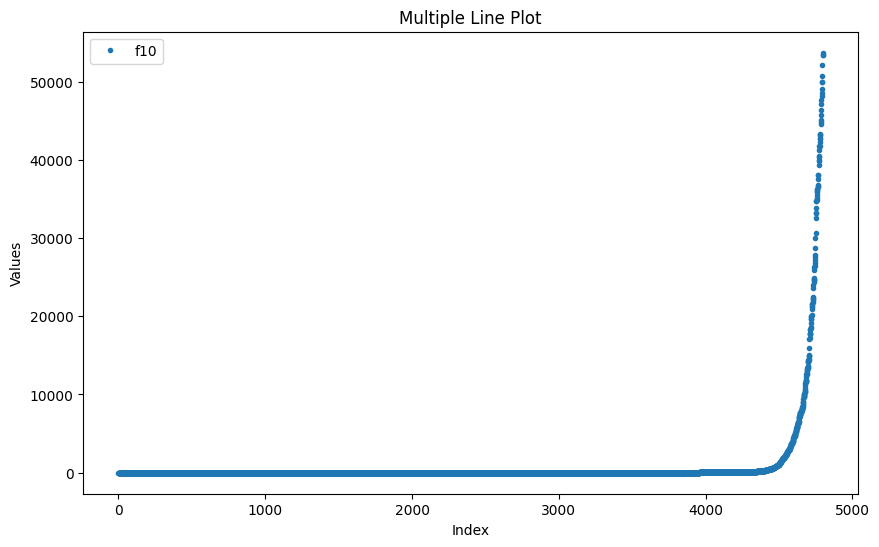

In [11]:
# 指定需要繪製的列
col2 = ['f10']
# 設定圖形大小
plt.figure(figsize=(10, 6))

# 循環遍歷每一列，並繪製每條線
for col in col2:
    plt.plot(df2.loc[:, col].sort_values().reset_index(drop=True), '.', label=col)  # 用 'dot' 標記

# 添加圖例
plt.legend()

# 添加標籤
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Multiple Line Plot')

# 顯示圖形
plt.show()

In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, Lambda
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 假設 df 已經是 pandas DataFrame
X = df2.iloc[:, :-1].values
y = df2.iloc[:, -1].values

# 將目標變數進行 one-hot encoding
y = to_categorical(y)

# 分割資料集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 對特徵進行標準化（可選）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 定義輸入層
input_layer = Input(shape=(X_train.shape[1],))

# 使用 Lambda 層分割特徵
sigmoid_features = Lambda(lambda x: x[:, :8])(input_layer)  # 前 9 個特徵
relu_features = Lambda(lambda x: x[:, 8:])(input_layer)    # 後面特徵

# 為前 9 個特徵添加 sigmoid 激活層
sigmoid_branch = Dense(16, activation='sigmoid')(sigmoid_features)

# 為其他特徵添加 ReLU 激活層
relu_branch = Dense(16, activation='tanh')(relu_features)

# 合併兩個分支
merged = Concatenate()([sigmoid_branch, relu_branch])

# 添加全連接層
hidden = Dense(32, activation='relu')(merged)
output_layer = Dense(y_train.shape[1], activation='softmax')(hidden)  # 輸出層

# 定義模型
model = Model(inputs=input_layer, outputs=output_layer)

# 編譯模型
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 訓練模型
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=2
)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {test_accuracy:.4f}")


Epoch 1/50
120/120 - 1s - 7ms/step - accuracy: 0.4354 - loss: 1.4661 - val_accuracy: 0.5708 - val_loss: 1.2135
Epoch 2/50
120/120 - 0s - 1ms/step - accuracy: 0.6224 - loss: 1.0624 - val_accuracy: 0.6438 - val_loss: 1.0066
Epoch 3/50
120/120 - 0s - 1ms/step - accuracy: 0.6674 - loss: 0.9227 - val_accuracy: 0.6552 - val_loss: 0.9390
Epoch 4/50
120/120 - 0s - 1ms/step - accuracy: 0.6922 - loss: 0.8628 - val_accuracy: 0.6677 - val_loss: 0.9048
Epoch 5/50
120/120 - 0s - 1ms/step - accuracy: 0.7036 - loss: 0.8318 - val_accuracy: 0.6750 - val_loss: 0.8840
Epoch 6/50
120/120 - 0s - 1ms/step - accuracy: 0.7104 - loss: 0.8111 - val_accuracy: 0.6823 - val_loss: 0.8789
Epoch 7/50
120/120 - 0s - 1ms/step - accuracy: 0.7138 - loss: 0.7946 - val_accuracy: 0.6865 - val_loss: 0.8671
Epoch 8/50
120/120 - 0s - 1ms/step - accuracy: 0.7198 - loss: 0.7822 - val_accuracy: 0.6906 - val_loss: 0.8696
Epoch 9/50
120/120 - 0s - 1ms/step - accuracy: 0.7206 - loss: 0.7741 - val_accuracy: 0.6875 - val_loss: 0.8558
E